In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import pandas as pd
from planetmagfields import Planet
import cartopy.crs as ccrs

# Make figures svg
%config InlineBackend.figure_formats = ['svg']

savefigs = True
if savefigs:
    os.makedirs('figures', exist_ok=True)

# Update x/y label and tick font sizes #Too big, need smaller font sizes
plt.rcParams.update({'font.size': 20})
plt.rcParams.update({'xtick.labelsize': 12})
plt.rcParams.update({'ytick.labelsize': 12})
plt.rcParams.update({'legend.fontsize': 12})

In [2]:
RU = 25600  # km
mag = pd.concat([pd.read_csv('./pds_data/1.92s/data-u1-1_92s-asc/T860124_ASC.csv'),
                 pd.read_csv('./pds_data/1.92s/data-u1-1_92s-asc/T860125_ASC.csv')],
                ignore_index=True)
pos = pd.read_csv('./pds_data/1.92s/vg2_positions_1_92s.csv')
mag['PDSTIME'] = pd.to_datetime(mag.PDSTIME, format='ISO8601', utc=True)
pos['PDSTIME'] = pd.to_datetime(pos.PDSTIME, format='ISO8601', utc=True)


df = mag.merge(pos, on='PDSTIME', how='inner')
r = pos['radius']/RU
theta = pos['colatitude']
phi = pos['longitude']

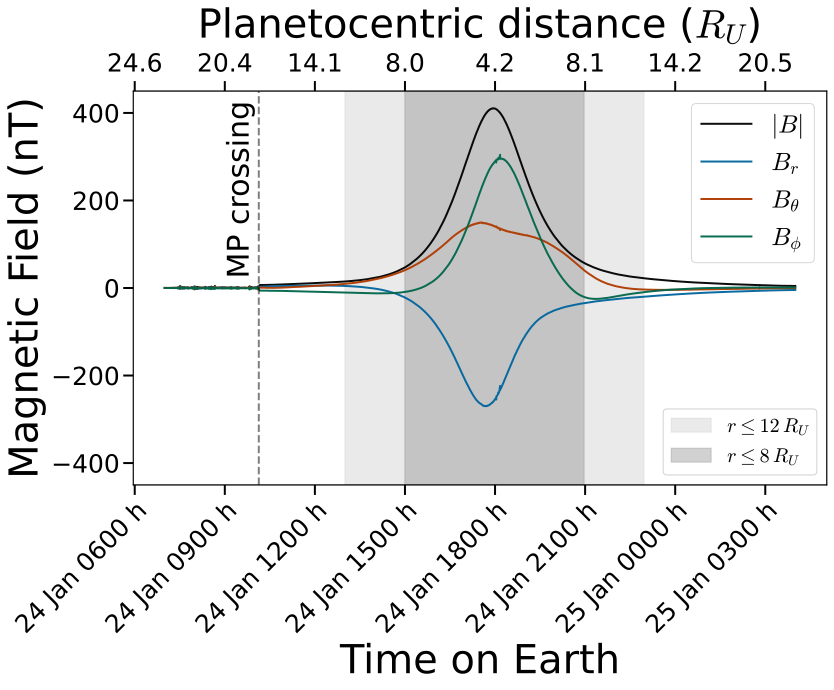

In [3]:
fig, ax = plt.subplots(figsize=(12, 10))

lw = 2
alpha = 0.95
# Darkened Okabe-Ito: colorblind-safe and dark enough to stay legible over the shaded bands.
colors = ["#00659E", "#B03A00", "#00664B"]


bmag = np.sqrt(df['BR']**2 + df['BTheta']**2 + df['BPhi']**2)

ax.plot(df['PDSTIME'], bmag, label=r'$|B|$', linewidth=lw, alpha=alpha, color='k')
ax.plot(df['PDSTIME'], df['BR'], label=r'$B_r$', linewidth=lw, alpha=alpha, color=colors[0])
ax.plot(df['PDSTIME'], df['BTheta'], label=r'$B_\theta$', linewidth=lw, alpha=alpha, color=colors[1])
ax.plot(df['PDSTIME'], df['BPhi'], label=r'$B_\phi$', linewidth=lw, alpha=alpha, color=colors[2])
ax.set_xlabel('Time on Earth', fontsize=40)
ax.set_ylabel('Magnetic Field (nT)', fontsize=40)
leg_field = ax.legend(fontsize=25, loc='upper right', frameon=True)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H%M h'))
ax.tick_params(axis='both', which='major', labelsize=25, length=10, width=2)

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# Align a top axis with the time ticks and label it with spacecraft distance.
time_ticks = ax.get_xticks()
time_num = mdates.date2num(df['PDSTIME'])
distance_ru = np.interp(time_ticks, time_num, df['radius'] / RU)
ax_distance = ax.twiny()
ax_distance.set_xlim(ax.get_xlim())
ax_distance.set_xticks(time_ticks)
ax_distance.set_xticklabels([f'{distance:.1f}' for distance in distance_ru])
ax_distance.set_xlabel(r'Planetocentric distance ($R_U$)', fontsize=40, labelpad=15)
ax_distance.tick_params(axis='x', which='major', labelsize=25, length=10, width=2)


def crossing_times(radius_ru):
    """Inbound and outbound times at which VG2 crossed a given planetocentric distance."""
    half = len(df) // 2
    dist = np.abs(df['radius'].values - radius_ru * RU)
    i_in = np.argmin(dist[:half])
    i_out = half + np.argmin(dist[half:])
    return df['PDSTIME'].iloc[i_in], df['PDSTIME'].iloc[i_out]


# Freeze the vertical extent so the shaded bands span the full panel.
ylim = [-450,450]#ax.get_ylim()
ax.set_ylim(ylim)

idx = np.argmin(np.abs(df['radius'][:len(df)//2] - 18 * RU))
ax.axvline(df['PDSTIME'].iloc[idx], color='k', linestyle='--', linewidth=2, alpha=0.5)
ax.text(df['PDSTIME'].iloc[idx-2000], 0.95*ylim[1], 'MP crossing', rotation=90, verticalalignment='top', fontsize=30)

# Data intervals used by the published internal-field models.
t12_in, t12_out = crossing_times(12)
t8_in, t8_out = crossing_times(8)

band12 = ax.fill_betweenx(ylim, t12_in, t12_out, color='#cccccc', alpha=0.4, zorder=0,
                          label=r'$r \leq 12\,R_U$')
band8 = ax.fill_betweenx(ylim, t8_in, t8_out, color='#8c8c8c', alpha=0.4, zorder=0,
                         label=r'$r \leq 8\,R_U$')

leg_models = ax.legend(handles=[band12, band8], loc='lower right', fontsize=20, framealpha=0.9)
ax.add_artist(leg_field)

# ax.grid(color='k', linestyle=':', linewidth=1, alpha=0.5)

fig.tight_layout()
if savefigs:
    plt.savefig('figures/uranus_magnetic_field_vg2.pdf', bbox_inches='tight')
plt.show()

In [6]:
mask = r <= 12

r = r[mask]; theta = theta[mask]; phi = phi[mask]
df = df[mask]
thetamax = 90-theta.max()*180/np.pi
thetamin = 90-theta.min()*180/np.pi
print(thetamin, thetamax)

51.83389335000001 -78.17902466000001


In [7]:
mask = r <= 8

r = r[mask]; theta = theta[mask]; phi = phi[mask]
df = df[mask]
thetamax = 90-theta.max()*180/np.pi
thetamin = 90-theta.min()*180/np.pi
print(thetamin, thetamax)

39.70256244000001 -78.09274026


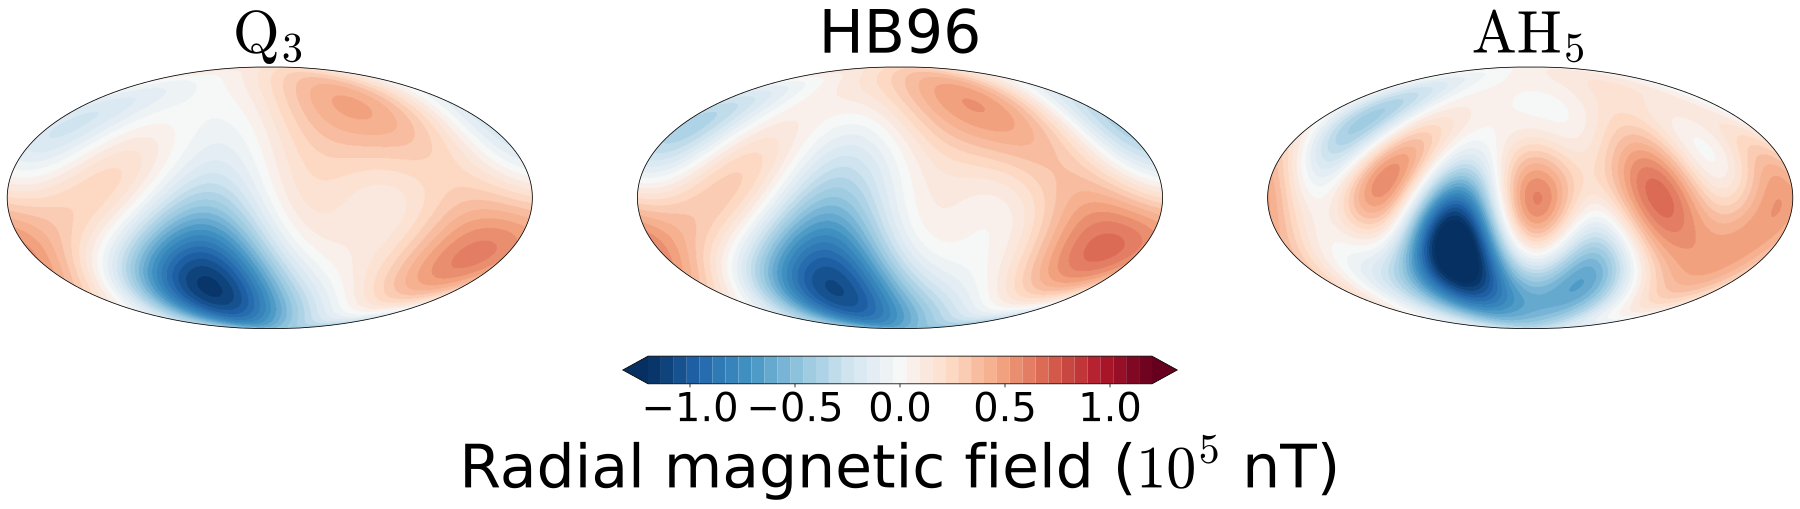

In [19]:
def plot_map(ax, lon, lat, Br, title):
    vmin, vmax = -1.2, 1.2
    cs = np.linspace(vmin, vmax, 40)
    cont = ax.contourf(lon, lat, Br/1e5, levels=cs, cmap='RdBu_r', transform=ccrs.PlateCarree(),zorder=-10, extend='both')
    ax.set_rasterization_zorder(-1)
    ax.set_title(title, fontsize=60)
    return cont


p1 = Planet("uranus",model="connerney1987",units="nT",info=False)
p2 = Planet("uranus",model="holme1996",units="nT",info=False)
p3 = Planet("uranus",model="herbert2009",units="nT",info=False)

lon2D = (p1.p2D - np.pi) * 180 / np.pi
lat2D = (np.pi/2 - p1.th2D) * 180 / np.pi

proj = ccrs.Mollweide()

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(32, 50), subplot_kw={'projection': proj})

cont1 = plot_map(ax[0], lon2D, lat2D, p1.Br, r"$\mathrm{Q_3}$")
cont2 = plot_map(ax[1], lon2D, lat2D, p2.Br, "HB96")
cont3 = plot_map(ax[2], lon2D, lat2D, p3.Br, r"$\mathrm{AH_5}$")


cbar = fig.colorbar(cont2, ax=ax, orientation='horizontal', fraction=0.01, pad=0.01)
cbar.set_label(r'Radial magnetic field ($10^5$ nT)', fontsize=60)
cbar.ax.tick_params(labelsize=40)
cbar.ax.set_xticks([-1, -0.5, 0, 0.5, 1])

# fig.tight_layout()
if savefigs:
    plt.savefig('figures/uranus_magnetic_field_models.pdf', bbox_inches='tight')
plt.show()